In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

In [10]:
!cd

C:\Users\nitin\PYL759\BTP\Project\src


## Configuration

In [15]:
DATASET = 'flickr30k'
IMG_SIZE = 256
RAW_DATA_PATH = os.path.join('..', 'data', 'raw', DATASET, 'flickr30k_images')
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed', f'{DATASET}_{IMG_SIZE}x{IMG_SIZE}_augmented')
NUM_TRAIN = 8000
NUM_VAL = 1000
NUM_TEST = 1000
TOTAL_IMAGES = NUM_TRAIN + NUM_VAL + NUM_TEST

## Simulation and Augmentation

In [12]:
def augment_image(image):
    if random.random() > 0.5:
        image = cv2.flip(image, 1)

    if random.random() > 0.5:
        image = cv2.flip(image, 0)

    angle = random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((IMG_SIZE // 2, IMG_SIZE // 2), angle, 1)
    image = cv2.warpAffine(image, M, (IMG_SIZE, IMG_SIZE))
    
    return image


def create_probes(shape, vortex_charge=1):
    ny, nx = shape
    x = np.linspace(-nx//2, nx//2, nx)
    y = np.linspace(-ny//2, ny//2, ny)
    xx, yy = np.meshgrid(x, y)
    sigma = IMG_SIZE / 4.0
    gaussian_amplitude = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    standard_probe = gaussian_amplitude.astype(np.complex64)

    # Vortex 
    phi = np.arctan2(yy, xx)
    vortex_phase = np.exp(1j * vortex_charge * phi)
    vortex_probe = gaussian_amplitude * vortex_phase
    vortex_probe = vortex_probe.astype(np.complex64)

    return standard_probe, vortex_probe

def simulate_diffraction(ground_truth, probe):
    obj_phase_map = np.pi * ground_truth
    obj_complex = np.exp(1j * obj_phase_map).astype(np.complex64)
    exit_wave = obj_complex * probe

    # Far-field diffraction pattern
    diffraction_pattern = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(exit_wave)))
    fourier_magnitude = np.abs(diffraction_pattern)
    fourier_magnitude = np.log1p(fourier_magnitude)
    
    # Normalization
    min_val, max_val = np.min(fourier_magnitude), np.max(fourier_magnitude)
    if max_val - min_val > 1e-6:
        fourier_magnitude = (fourier_magnitude - min_val) / (max_val - min_val)
    else:
        fourier_magnitude = np.zeros_like(fourier_magnitude)

    return fourier_magnitude.astype(np.float32)

## Main Code

In [13]:
def process_and_save(image_files, split_name, probes):
    print(f"Processing {split_name} set with {len(image_files)} images")
    standard_probe, vortex_probe = probes

    # Define paths
    gt_path = os.path.join(PROCESSED_DATA_PATH, split_name, 'ground_truth')
    input_standard_path = os.path.join(PROCESSED_DATA_PATH, split_name, 'input_standard')
    input_vortex_path = os.path.join(PROCESSED_DATA_PATH, split_name, 'input_vortex')

    for filename in tqdm(image_files):
        try:
            img_path = os.path.join(RAW_DATA_PATH, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None: continue

            # Resize and pad to the target size
            h, w = img.shape
            scale = IMG_SIZE / max(h, w)
            img_resized = cv2.resize(img, (int(w * scale), int(h * scale)))
            
            delta_h, delta_w = IMG_SIZE - img_resized.shape[0], IMG_SIZE - img_resized.shape[1]
            top, bottom = delta_h // 2, delta_h - (delta_h // 2)
            left, right = delta_w // 2, delta_w - (delta_w // 2)
            
            img_padded = cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)
            ground_truth = img_padded.astype(np.float32) / 255.0

            if split_name == 'train':
                ground_truth = augment_image(ground_truth)

            # Simulate diffraction for both illuminations
            input_standard = simulate_diffraction(ground_truth, standard_probe)
            input_vortex = simulate_diffraction(ground_truth, vortex_probe)

            # Save the processed data
            base_filename = os.path.splitext(filename)[0]
            np.save(os.path.join(gt_path, f"{base_filename}.npy"), ground_truth)
            np.save(os.path.join(input_standard_path, f"{base_filename}.npy"), input_standard)
            np.save(os.path.join(input_vortex_path, f"{base_filename}.npy"), input_vortex)

        except Exception as e:
            print(f"Error processing {filename}: {e}")

In [ ]:
if __name__ == '__main__':
    print("Starting Dataset Creation")
    
    print("Step 1: Creating directory structure")
    for split in ['train', 'val', 'test']:
        for folder in ['ground_truth', 'input_standard', 'input_vortex']:
            os.makedirs(os.path.join(PROCESSED_DATA_PATH, split, folder), exist_ok=True)
    
    all_images = [f for f in os.listdir(RAW_DATA_PATH) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if len(all_images) < TOTAL_IMAGES:
        raise ValueError(f"Not enough images. Found {len(all_images)}, need {TOTAL_IMAGES}.")
        
    random.seed(42)
    random.shuffle(all_images)
    
    train_files = all_images[:NUM_TRAIN]
    val_files = all_images[NUM_TRAIN:NUM_TRAIN + NUM_VAL]
    test_files = all_images[NUM_TRAIN + NUM_VAL:TOTAL_IMAGES]
    print(f"Dataset splits: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test.")

    print("\nStep 2: Generating illumination probes...")
    std_probe, vor_probe = create_probes(shape=(IMG_SIZE, IMG_SIZE))

    # Verification: Visualize Probes
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(np.abs(std_probe), cmap='gray')
    axes[0].set_title('Standard Probe (Amplitude)')
    axes[1].imshow(np.angle(vor_probe), cmap='hsv')
    axes[1].set_title('Vortex Probe (Phase)')
    plt.suptitle("Verification: Illumination Probes")
    plt.show()

    print("\nStep 3: Processing and saving datasets...")
    probes = (std_probe, vor_probe)
    process_and_save(train_files, 'train', probes)
    process_and_save(val_files, 'val', probes)
    process_and_save(test_files, 'test', probes)

    # Verification: Visualize an augmented sample
    print("\nStep 4: Final verification check...")
    sample_name = os.path.splitext(train_files[0])[0]
    gt_sample = np.load(os.path.join(PROCESSED_DATA_PATH, 'train', 'ground_truth', f'{sample_name}.npy'))
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv2.imread(os.path.join(RAW_DATA_PATH, train_files[0]), cv2.IMREAD_GRAYSCALE), cmap='gray')
    axes[0].set_title('Original Image')
    axes[1].imshow(gt_sample, cmap='gray')
    axes[1].set_title('Augmented Ground Truth (Sample)')
    plt.suptitle("Verification: Augmentation")
    plt.show()
    
    print("\n--- Dataset Creation Complete ---")```

Starting Dataset Creation
Step 1: Creating directory structure...
Dataset splits: 8000 train, 1000 val, 1000 test, and 15 debug.

Step 2: Generating illumination probes

Step 3: Processing and saving datasets
Processing train set with 8000 images


100%|██████████████████████████████████████████████████████████████████████████████| 8000/8000 [06:35<00:00, 20.24it/s]


Processing val set with 1000 images


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:46<00:00, 21.28it/s]


Processing test set with 1000 images


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:46<00:00, 21.45it/s]


Processing debug set with 15 images


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 29.94it/s]



Step 4: Final verification check using a debug sample


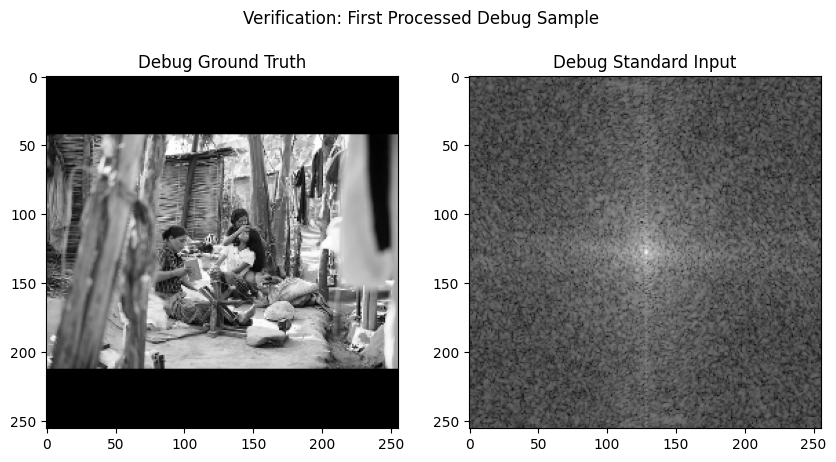


Dataset Creation Complete


In [16]:
if __name__ == '__main__':
    print("Starting Dataset Creation")

    NUM_DEBUG = 15

    print("Step 1: Creating directory structure...")
    for split in ['train', 'val', 'test', 'debug']:
        for folder in ['ground_truth', 'input_standard', 'input_vortex']:
            os.makedirs(os.path.join(PROCESSED_DATA_PATH, split, folder), exist_ok=True)
    
    all_images = [f for f in os.listdir(RAW_DATA_PATH) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if len(all_images) < TOTAL_IMAGES:
        raise ValueError(f"Not enough images. Found {len(all_images)}, need {TOTAL_IMAGES}.")
        
    random.seed(42)
    random.shuffle(all_images)
    
    train_files = all_images[:NUM_TRAIN]
    val_files = all_images[NUM_TRAIN:NUM_TRAIN + NUM_VAL]
    test_files = all_images[NUM_TRAIN + NUM_VAL:TOTAL_IMAGES]
    debug_files = train_files[:NUM_DEBUG] 
    print(f"Dataset splits: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test, and {len(debug_files)} debug.")

    print("\nStep 2: Generating illumination probes")
    std_probe, vor_probe = create_probes(shape=(IMG_SIZE, IMG_SIZE))

    print("\nStep 3: Processing and saving datasets")
    probes = (std_probe, vor_probe)
    process_and_save(train_files, 'train', probes)
    process_and_save(val_files, 'val', probes)
    process_and_save(test_files, 'test', probes)
    process_and_save(debug_files, 'debug', probes)

    print("\nStep 4: Final verification check using a debug sample")
    sample_name = os.path.splitext(debug_files[0])[0]
    gt_sample = np.load(os.path.join(PROCESSED_DATA_PATH, 'debug', 'ground_truth', f'{sample_name}.npy'))
    std_sample = np.load(os.path.join(PROCESSED_DATA_PATH, 'debug', 'input_standard', f'{sample_name}.npy'))
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gt_sample, cmap='gray')
    axes[0].set_title('Debug Ground Truth')
    axes[1].imshow(std_sample, cmap='gray')
    axes[1].set_title('Debug Standard Input')
    plt.suptitle("Verification: First Processed Debug Sample")
    plt.show()
    
    print("\nDataset Creation Complete")

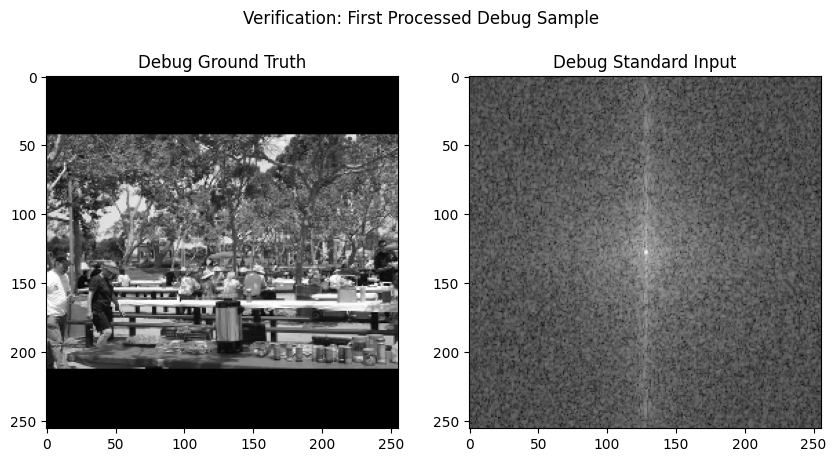

In [21]:
sample_name = os.path.splitext(debug_files[3])[0]
gt_sample = np.load(os.path.join(PROCESSED_DATA_PATH, 'debug', 'ground_truth', f'{sample_name}.npy'))
std_sample = np.load(os.path.join(PROCESSED_DATA_PATH, 'debug', 'input_standard', f'{sample_name}.npy'))
    
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gt_sample, cmap='gray')
axes[0].set_title('Debug Ground Truth')
axes[1].imshow(std_sample, cmap='gray')
axes[1].set_title('Debug Standard Input')
plt.suptitle("Verification: First Processed Debug Sample")
plt.show()